# Evaluation Analysis

Loads pre-computed results from the current pipeline: `evaluation/eval_utility.py`
(TSTR/TRTR/retention) and `evaluation/eval_fidelity.py` (SDMetrics), both as
mean ± std over `seeds.RUN_SEEDS`, plus `results/computational_cost.csv`.

Does **not** recompute anything — run those scripts first.

**Privacy cells below are LEGACY** (iteration 1/2, `results/tapas_LEGACY/`) and are not
going into the write-up. The current privacy results live in `benchmark_tapas/`.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

RESULTS = Path('../results')


# Repo palette (from the reference chart): orange + grey primary, teal + pink accent.
ORANGE, GREY, TEAL, PINK = "#CE4E36", "#3A3A3A", "#8CA9A0", "#D2B4B1"
# 5th slot for AIM - the 4-colour palette had no free step. Slate blue is separable
# from all four and is not the limiting pair (see palette note below).
SLATE = "#6B7F99"

METHOD_ORDER  = ['bayesian_network', 'privbayes', 'ctgan', 'dpgan', 'aim']
METHOD_LABELS = {
    'bayesian_network': 'BN',
    'privbayes':        'PrivBayes',
    'ctgan':            'CTGAN',
    'dpgan':            'DPGAN',
    'aim':              'AIM',
}
COLORS = {
    'bayesian_network': ORANGE,
    'privbayes':        GREY,
    'ctgan':            TEAL,
    'dpgan':            PINK,
    'aim':              SLATE,
}

# TAPAS has only been run for the original four generators, so the privacy plots use
# this order instead. Do NOT use METHOD_ORDER there: AIM's privacy cells are NaN, and
# the eff-epsilon cell maps non-finite values to INF_CAP - which would draw AIM as
# maximally leaking rather than as 'not yet measured'.
PRIVACY_ORDER = ['bayesian_network', 'privbayes', 'ctgan', 'dpgan']

# Palette note: CTGAN (teal) vs DPGAN (pink) separate by only dE 10.8 in normal vision
# and 5.9 under protanopia, below the dE 15 / 8 floors. Every chart below also labels
# methods on the x-axis or directly, so identity is never colour-alone - that is the
# required relief. Worth re-stepping if these ever appear without labels.

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## Load results

In [3]:
# Utility + fidelity now come from the in-house multi-run tables (mean +/- std over
# seeds.RUN_SEEDS), not synthcity. results/synthcity_results.csv has been DELETED:
# its TSTR was scored on an internal split of the generators' own training data,
# so memorisation was rewarded. See evaluation/eval_utility.py for the replacement.
util_raw = pd.read_csv(RESULTS / 'utility_summary.csv')     # <- evaluation/eval_utility.py
fid_raw  = pd.read_csv(RESULTS / 'fidelity_summary.csv')    # <- evaluation/eval_fidelity.py

# TAPAS below is iteration 1 (LEGACY), kept only so the older privacy plots still run.
# The correct privacy results live in benchmark_tapas/ and are NOT loaded here.
tap = pd.read_csv(RESULTS / 'tapas_LEGACY' / 'tapas_results.csv')

print('Utility (in-house):  ', util_raw.shape)
print('Fidelity (in-house): ', fid_raw.shape)
print('TAPAS (LEGACY iter 1):', tap.shape)


Synthcity: (40, 11)
SDMetrics: (5, 5)
TAPAS:     (4, 13)


In [4]:
# LEGACY (iteration 2): effective epsilon for PrivBayes only. Superseded by
# benchmark_tapas/ -- kept so the earlier numbers stay reachable.
effeps_privbayes = pd.read_csv(RESULTS / 'tapas_LEGACY' / 'tapas_results' /
                               'eff_eps_results' / 'privbayes' / 'effeps_privbayes.csv')
effeps_privbayes[["attack", "eps_low_90", "eps_high_90",
                  "eps_low_95", "eps_high_95", "eps_low_99", "eps_high_99"]]


,attack,eps_low_90,eps_high_90,eps_low_95,eps_high_95,eps_low_99,eps_high_99
0,Groundhog,2.390153,inf,2.209964,inf,1.878477,inf
1,ShadowModelling(RandomQueries),2.390153,inf,2.209964,inf,1.878477,inf
2,"LocalNeighbourhood(L_2, 0.250411558405805, acc...",0.000000,0.085788,0.000000,0.101908,0.000000,0.139336
3,ProbabilityEstimation(KernelDensity()),0.000000,0.085788,0.000000,0.101908,0.000000,0.139336


In [5]:
# Both summary tables are wide already: one row per method, a _mean and a _std per
# metric. Split each into a mean frame and a std frame, indexed by method label.
FIDELITY_STEMS = ['KSComplement', 'TVComplement',
                  'CorrelationSimilarity', 'ContingencySimilarity']
UTILITY_STEMS  = ['tstr_xgboost_auc', 'trtr_xgboost_auc', 'retention_xgboost',
                  'tstr_logistic_regression_auc', 'trtr_logistic_regression_auc',
                  'retention_logistic_regression']

def mean_std(raw, stems):
    d = raw.set_index('method').reindex(METHOD_ORDER)
    d.index = [METHOD_LABELS[m] for m in d.index]
    mean = pd.DataFrame({s: d[f'{s}_mean'] for s in stems if f'{s}_mean' in d}, index=d.index)
    sd   = pd.DataFrame({s: d[f'{s}_std']  for s in stems if f'{s}_std'  in d}, index=d.index)
    return mean, sd

# `sdm` keeps its old name so the fidelity cells below are unchanged; its columns are
# now run means rather than a single draw.
sdm, sdm_sd = mean_std(fid_raw, FIDELITY_STEMS)
util, util_sd = mean_std(util_raw, UTILITY_STEMS)
print('n runs per method:', util_raw.set_index('method')['n_runs'].to_dict())


['method', 'min', 'max', 'mean', 'stddev', 'median', 'iqr', 'rounds', 'errors', 'durations', 'direction']


,method,min,max,mean,stddev,median,iqr,rounds,errors,durations,direction
performance.linear_model.gt,bayesian_network,8.094591e-01,8.094591e-01,8.094591e-01,0.0,8.094591e-01,0.0,1,0,0.02,maximize
performance.linear_model.syn_id,bayesian_network,6.653153e-01,6.653153e-01,6.653153e-01,0.0,6.653153e-01,0.0,1,0,0.02,maximize
performance.linear_model.syn_ood,bayesian_network,6.627646e-01,6.627646e-01,6.627646e-01,0.0,6.627646e-01,0.0,1,0,0.02,maximize
performance.xgb.gt,bayesian_network,9.198841e-01,9.198841e-01,9.198841e-01,0.0,9.198841e-01,0.0,1,0,0.02,maximize
performance.xgb.syn_id,bayesian_network,7.672858e-01,7.672858e-01,7.672858e-01,0.0,7.672858e-01,0.0,1,0,0.02,maximize
performance.xgb.syn_ood,bayesian_network,7.758381e-01,7.758381e-01,7.758381e-01,0.0,7.758381e-01,0.0,1,0,0.02,maximize
performance.feat_rank_distance.corr,bayesian_network,2.251508e-01,2.251508e-01,2.251508e-01,0.0,2.251508e-01,0.0,1,0,0.21,minimize
performance.feat_rank_distance.pvalue,bayesian_network,1.042902e-108,1.042902e-108,1.042902e-108,0.0,1.042902e-108,0.0,1,0,0.21,minimize
performance.linear_model.gt,privbayes,8.094591e-01,8.094591e-01,8.094591e-01,0.0,8.094591e-01,0.0,1,0,0.02,maximize
performance.linear_model.syn_id,privbayes,7.805903e-01,7.805903e-01,7.805903e-01,0.0,7.805903e-01,0.0,1,0,0.02,maximize


In [6]:
# Utility, mean over runs. TSTR/TRTR are both AUC on the SAME 5,381-record holdout.
util.round(4)


metric,performance.feat_rank_distance.corr,performance.feat_rank_distance.pvalue,performance.linear_model.gt,performance.linear_model.syn_id,performance.linear_model.syn_ood,performance.xgb.gt,performance.xgb.syn_id,performance.xgb.syn_ood
BN,0.225151,1.042902e-108,0.809459,0.665315,0.662765,0.919884,0.767286,0.775838
PrivBayes,0.613909,0.000000e+00,0.809459,0.780590,0.784267,0.919884,0.882615,0.887115
CTGAN,0.443831,0.000000e+00,0.809459,0.746046,0.748458,0.919884,0.871867,0.871520
DPGAN,-0.028361,5.269805e-03,0.809459,0.756558,0.759812,0.919884,0.393917,0.394588
AIM,0.053236,1.629547e-07,0.809411,0.658474,0.650485,0.919884,0.723946,0.728792


In [7]:
# Fidelity, mean over runs (synthetic vs training data).
sdm.round(4)


,KSComplement,TVComplement,CorrelationSimilarity,ContingencySimilarity
BN,0.728923,0.896982,0.972600,0.788836
PrivBayes,0.935975,0.946580,0.968712,0.877143
CTGAN,0.705561,0.852280,0.985434,0.727693
DPGAN,0.199099,0.209816,0.955723,0.058544
AIM,0.909474,0.982710,0.796305,0.911648


In [8]:
# TAPAS — already wide
tap = tap.set_index('method').reindex(METHOD_ORDER)
tap.index = [METHOD_LABELS[m] for m in tap.index]
tap

,mia_auc,mia_advantage,mia_privacy_gain,mia_eff_epsilon,mia_tp,mia_fp,aia_auc,aia_advantage,aia_privacy_gain,aia_eff_epsilon,eps_low_90,eps_high_90
BN,0.514911,0.046667,0.953333,1.203973,0.523333,0.476667,0.755543,0.207067,0.792933,3.799172,0.0,0.030240
PrivBayes,0.498189,-0.006667,1.006667,0.302281,0.496667,0.503333,0.834531,0.306658,0.693342,inf,0.0,0.018037
CTGAN,0.461489,-0.073333,1.073333,0.980829,0.463333,0.536667,0.874886,0.444876,0.555124,inf,0.0,0.013562
DPGAN,0.506633,0.040000,0.960000,0.788457,0.520000,0.480000,0.730269,0.024264,0.975736,inf,0.0,0.037938
AIM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Utility retention = TSTR / TRTR, both scored on the same 5,381-record holdout,
# so this is a like-for-like ratio. Computed in eval_utility.py; read back here
# with its across-run spread.
ret = pd.DataFrame({
    'retention_xgb':    util['retention_xgboost'],
    'retention_xgb_sd': util_sd['retention_xgboost'],
    'retention_lr':     util['retention_logistic_regression'],
    'retention_lr_sd':  util_sd['retention_logistic_regression'],
})
ret.round(4)


,ret_ood,ret_id
BN,0.8434,0.8341
PrivBayes,0.9644,0.9595
CTGAN,0.9474,0.9478
DPGAN,0.4290,0.4282
AIM,0.7923,0.7870


## Master comparison table

In [10]:
# Pull key metrics from each source
key_utility  = ['BinaryLogisticRegression_F1', 'LogisticDetection']
key_fidelity = ['KSComplement', 'TVComplement', 'CorrelationSimilarity', 'ContingencySimilarity']
key_privacy  = ['DCRBaselineProtection', 'NewRowSynthesis',
                'mia_auc', 'mia_advantage', 'mia_eff_epsilon',
                'aia_auc', 'aia_eff_epsilon', 'eps_low_90', 'eps_high_90']

master = pd.concat([
    sdm[key_fidelity],
    sdm[[c for c in key_utility if c in sdm.columns]],
    tap[[c for c in key_privacy if c in tap.columns]],
], axis=1)

master.round(4)

,KSComplement,TVComplement,CorrelationSimilarity,ContingencySimilarity,mia_auc,mia_advantage,mia_eff_epsilon,aia_auc,aia_eff_epsilon,eps_low_90,eps_high_90
BN,0.7289,0.8970,0.9726,0.7888,0.5149,0.0467,1.2040,0.7555,3.7992,0.0,0.0302
PrivBayes,0.9360,0.9466,0.9687,0.8771,0.4982,-0.0067,0.3023,0.8345,inf,0.0,0.0180
CTGAN,0.7056,0.8523,0.9854,0.7277,0.4615,-0.0733,0.9808,0.8749,inf,0.0,0.0136
DPGAN,0.1991,0.2098,0.9557,0.0585,0.5066,0.0400,0.7885,0.7303,inf,0.0,0.0379
AIM,0.9095,0.9827,0.7963,0.9116,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Plot 1 — Fidelity comparison

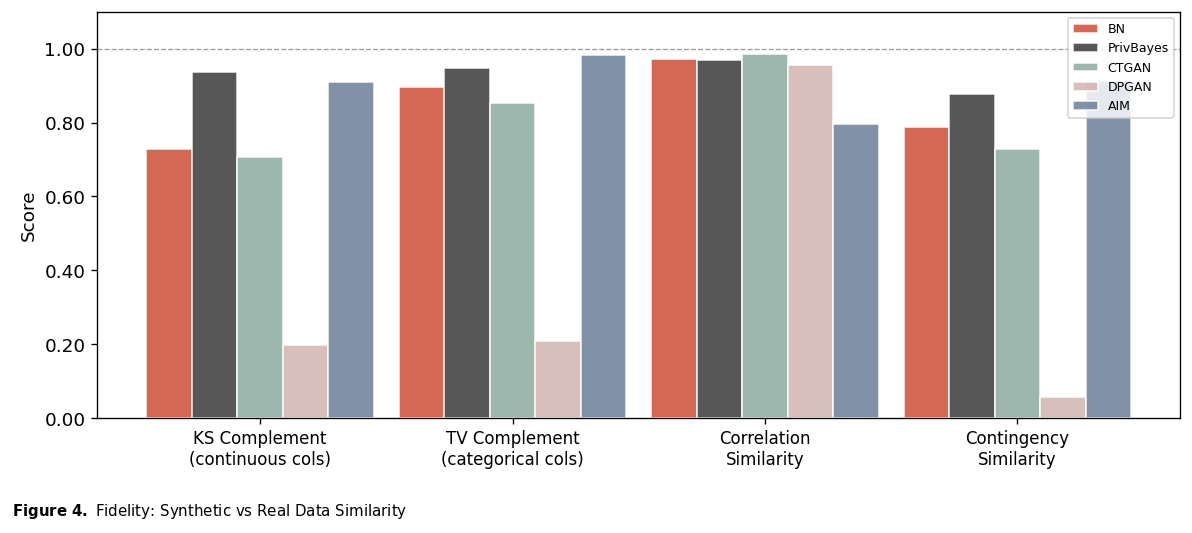

In [11]:
fidelity_metrics = ['KSComplement', 'TVComplement', 'CorrelationSimilarity', 'ContingencySimilarity']
fidelity_labels  = ['KS Complement\n(continuous cols)', 'TV Complement\n(categorical cols)',
                     'Correlation\nSimilarity', 'Contingency\nSimilarity']

available = [m for m in fidelity_metrics if m in master.columns]
n = len(available)
x = np.arange(n)
width = 0.18

fig, ax = plt.subplots(figsize=(10, 4.5))
for i, (method, label) in enumerate(zip(METHOD_ORDER, METHOD_LABELS.values())):
    label_str = METHOD_LABELS[method]
    if label_str in master.index:
        vals = [master.loc[label_str, m] if m in master.columns else np.nan for m in available]
        ax.bar(x + (i - (len(METHOD_ORDER) - 1) / 2) * width, vals, width, label=label_str,
               color=COLORS[method], alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([fidelity_labels[fidelity_metrics.index(m)] for m in available], fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.axhline(1.0, color=GREY, linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(loc='upper right', fontsize=7.5)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
# Leave space at the bottom for caption
plt.tight_layout(rect=[0, 0.08, 1, 1])

# Add left-aligned caption
fig.text(
    0.01,
    0.02,
    r"$\bf{Figure\ 4.}$ Fidelity: Synthetic vs Real Data Similarity",
    ha="left",
    va="bottom",
    fontsize=9
)

plt.savefig(RESULTS / 'fidelity_comparison.png', bbox_inches='tight')
plt.show()

## Plot 2 — Utility vs Privacy tradeoff

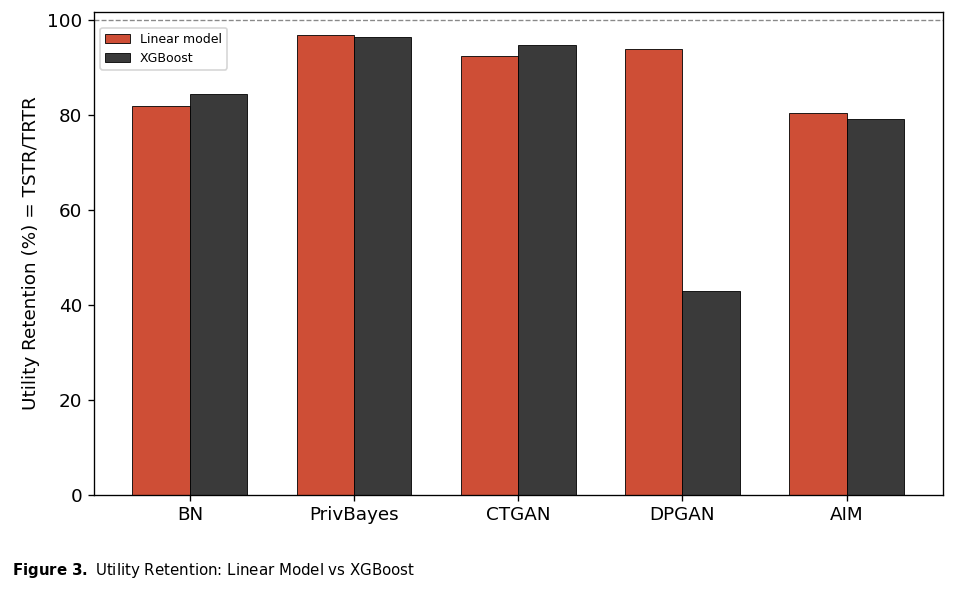

In [12]:
# Utility retention = TSTR / TRTR x 100, both scored on the same 5,381-record
# holdout. Error bars are the across-seed std over seeds.RUN_SEEDS -- worth reading
# before comparing bars: at eps=1.0 the DP methods' spread can be wide enough to
# overlap their non-DP siblings.
fig, ax = plt.subplots(figsize=(8, 5))

labels = [METHOD_LABELS[m] for m in METHOD_ORDER]
x = np.arange(len(labels))
width = 0.35

lr_ret  = [100 * util.loc[l, 'retention_logistic_regression'] for l in labels]
xgb_ret = [100 * util.loc[l, 'retention_xgboost'] for l in labels]
lr_err  = [100 * util_sd.loc[l, 'retention_logistic_regression'] for l in labels]
xgb_err = [100 * util_sd.loc[l, 'retention_xgboost'] for l in labels]

ax.bar(x - width/2, lr_ret, width, yerr=lr_err, capsize=3, label='Logistic regression',
       color=ORANGE, edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, xgb_ret, width, yerr=xgb_err, capsize=3, label='XGBoost',
       color=GREY, edgecolor='black', linewidth=0.5)

ax.axhline(100, ls='--', lw=1, color=TEAL, zorder=1)
ax.text(len(labels) - 0.4, 101, 'real-data baseline (TRTR)', fontsize=8,
        color=TEAL, ha='right', va='bottom')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('AUC retention vs real-data baseline (%)')
ax.set_title('Utility retention — TSTR / TRTR, held-out test set (n = 5,381)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

plt.savefig(RESULTS / 'utility_metric_comparison.png', bbox_inches='tight')
plt.show()


### Plot 2b — utility vs privacy tradeoff: SUPERSEDED

This cell plotted in-house utility against **iteration-1** TAPAS `mia_auc`, which is
now in `results/tapas_LEGACY/` and is not going in the write-up.

The current version of this figure is
`benchmark_tapas/analysis/tradeoff.py` → `benchmark_tapas/results/figures/privacy_utility_tradeoff.png`:
5-attack mean membership advantage on the privacy axis, in-house TSTR with
across-seed error bars on the utility axis. Use that one.


## Plot 3 — Effective epsilon (ε_eff) comparison

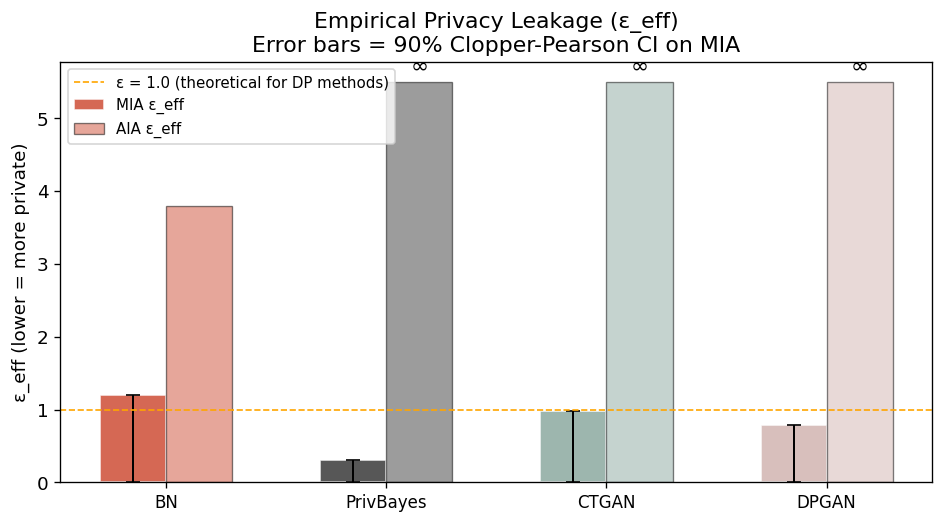

In [14]:
# aia_eff_epsilon is inf when AIA FP rate = 0 (ln(TP/0) = inf)
# Cap at INF_CAP for display and annotate with ∞ symbol
INF_CAP = 5.5

fig, ax = plt.subplots(figsize=(8, 4.5))

labels_plot = [METHOD_LABELS[m] for m in PRIVACY_ORDER if METHOD_LABELS[m] in master.index]
x = np.arange(len(labels_plot))
colors_plot = [COLORS[m] for m in PRIVACY_ORDER if METHOD_LABELS[m] in master.index]

mia_eps     = [master.loc[l, 'mia_eff_epsilon'] if 'mia_eff_epsilon' in master.columns else np.nan
               for l in labels_plot]
aia_eps_raw = [master.loc[l, 'aia_eff_epsilon'] if 'aia_eff_epsilon' in master.columns else np.nan
               for l in labels_plot]
eps_low     = [master.loc[l, 'eps_low_90']  if 'eps_low_90'  in master.columns else np.nan for l in labels_plot]
eps_high    = [master.loc[l, 'eps_high_90'] if 'eps_high_90' in master.columns else np.nan for l in labels_plot]

aia_eps = [min(v, INF_CAP) if np.isfinite(v) else INF_CAP for v in aia_eps_raw]

width = 0.3
ax.bar(x - width/2, mia_eps, width, label='MIA ε_eff', color=colors_plot, alpha=0.85, edgecolor='white')
ax.bar(x + width/2, aia_eps, width, label='AIA ε_eff', color=colors_plot, alpha=0.5,
       edgecolor='black', linewidth=0.8)

# Annotate bars capped from inf
for xi, (raw, capped) in enumerate(zip(aia_eps_raw, aia_eps)):
    if not np.isfinite(raw):
        ax.text(xi + width/2, capped + 0.08, '∞', ha='center', va='bottom', fontsize=13)

# CP bounds on MIA as error bars
eps_err_low  = np.array([max(0, m - l) for m, l in zip(mia_eps, eps_low)])
eps_err_high = np.array([max(0, h - m) for m, h in zip(mia_eps, eps_high)])
ax.errorbar(x - width/2, mia_eps,
            yerr=[eps_err_low, eps_err_high],
            fmt='none', color='black', capsize=4, linewidth=1.2)

ax.axhline(1.0, color='orange', linestyle='--', linewidth=1,
           label='ε = 1.0 (theoretical for DP methods)')
ax.set_xticks(x)
ax.set_xticklabels(labels_plot, fontsize=10)
ax.set_ylabel('ε_eff (lower = more private)')
ax.set_title('Empirical Privacy Leakage (ε_eff)\nError bars = 90% Clopper-Pearson CI on MIA')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS / 'epsilon_comparison.png', bbox_inches='tight')
plt.show()

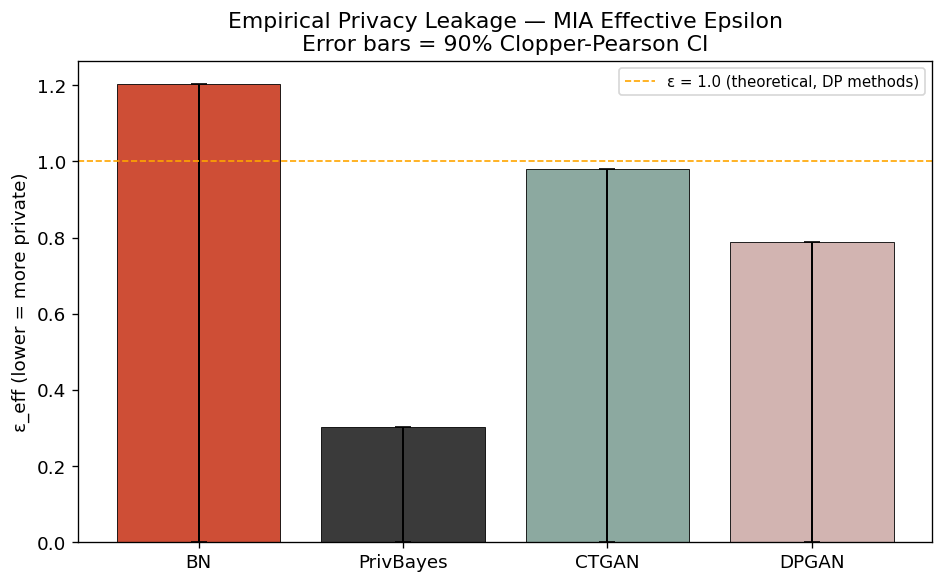

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

mia_eps = [master.loc[METHOD_LABELS[m], 'mia_eff_epsilon'] for m in PRIVACY_ORDER]
eps_low = [master.loc[METHOD_LABELS[m], 'eps_low_90'] for m in PRIVACY_ORDER]
eps_high = [master.loc[METHOD_LABELS[m], 'eps_high_90'] for m in PRIVACY_ORDER]

# error bars need [value - low, high - value], clipped at 0
err_lower = [max(0, v - lo) for v, lo in zip(mia_eps, eps_low)]
err_upper = [max(0, hi - v) for v, hi in zip(mia_eps, eps_high)]

ax.bar(np.arange(len(PRIVACY_ORDER)), mia_eps,
       color=[COLORS[m] for m in PRIVACY_ORDER], edgecolor='black', linewidth=0.5,
       yerr=[err_lower, err_upper], capsize=5, error_kw={'elinewidth': 1.2})

ax.axhline(1.0, color='orange', linestyle='--', linewidth=1, label='ε = 1.0 (theoretical, DP methods)')
ax.set_ylabel('ε_eff (lower = more private)', fontsize=11)
ax.set_xticks(np.arange(len(PRIVACY_ORDER)))
ax.set_xticklabels([METHOD_LABELS[m] for m in PRIVACY_ORDER])
ax.set_title('Empirical Privacy Leakage — MIA Effective Epsilon\nError bars = 90% Clopper-Pearson CI')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS / 'mia_effective_epsilon.png', bbox_inches='tight')
plt.show()

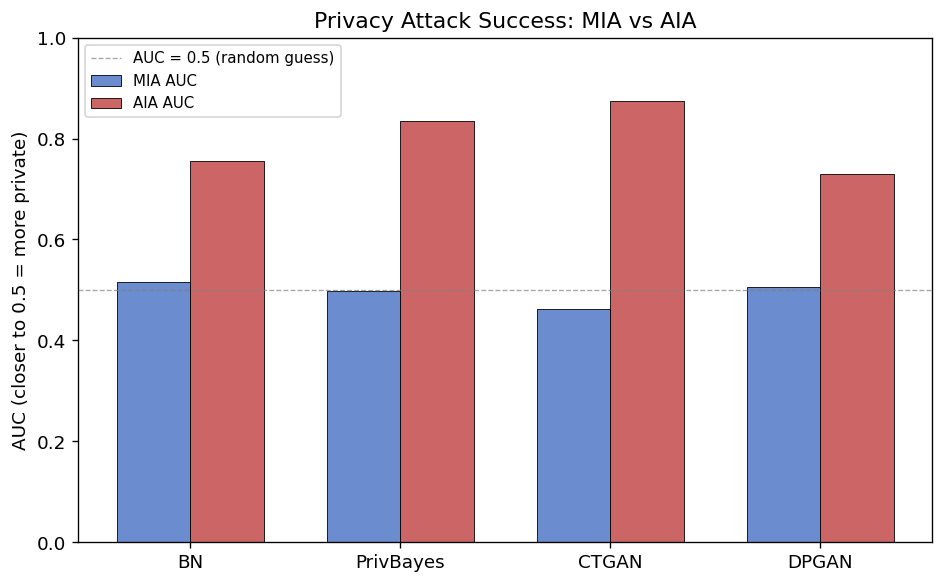

In [16]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(PRIVACY_ORDER))
width = 0.35

mia_auc = [master.loc[METHOD_LABELS[m], 'mia_auc'] for m in PRIVACY_ORDER]
aia_auc = [master.loc[METHOD_LABELS[m], 'aia_auc'] for m in PRIVACY_ORDER]

ax.bar(x - width/2, mia_auc, width, label='MIA AUC', color='#6b8cce', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, aia_auc, width, label='AIA AUC', color='#cc6666', edgecolor='black', linewidth=0.5)

ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.7, label='AUC = 0.5 (random guess)')
ax.set_ylabel('AUC (closer to 0.5 = more private)', fontsize=11)
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels([METHOD_LABELS[m] for m in PRIVACY_ORDER])
ax.set_title('Privacy Attack Success: MIA vs AIA')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS / 'privacy_attack_success.png', bbox_inches='tight')
plt.show()

## Overhead summary

In [17]:
# Computational cost: generation + fidelity + utility, per (method, seed, stage).
# Replaces evaluation/eval_overhead.csv (now evaluation_LEGACY/eval_overhead_LEGACY.csv),
# which timed whole script invocations and only covered the superseded eval scripts.
cost_path = RESULTS / 'computational_cost.csv'
if cost_path.exists():
    cost = pd.read_csv(cost_path)
    display(cost.groupby(['method', 'stage', 'device'], sort=False).agg(
        n_runs=('seed', 'count'),
        wall_clock_s_mean=('wall_clock_s', 'mean'),
        wall_clock_s_std=('wall_clock_s', 'std'),
        peak_memory_mb_mean=('peak_memory_mb', 'mean'),
    ).round(2))
    print('Peak memory is Python-level only (tracemalloc) -- it does not see torch CUDA')
    print('or jax buffers, so it understates the neural methods and AIM. Use wall clock')
    print('for cross-method comparison.')
else:
    print('computational_cost.csv not found - run sdg/generate_runs.py and the eval scripts first')


,script,runtime_sec,peak_memory_mb,methods_succeeded,methods_failed
0,eval_synthcity_bayesian_network,0.61,29.48,1,0
1,eval_synthcity_privbayes,0.58,29.48,1,0
2,eval_synthcity_ctgan,0.60,29.78,1,0
3,eval_synthcity_dpgan,0.59,30.08,1,0
4,eval_sdmetrics,3.13,10.85,5,0
5,eval_synthcity_aim,4.25,38.70,1,0


## AIM bin-count tuning

**Question:** at ε = 1.0, does bin count determine whether AIM ever buys a numerical × numerical marginal — and where does utility peak?

AIM needs an all-discrete domain, so the 5 continuous columns are binned before fitting and decoded after. Bin count is AIM's one free preprocessing parameter. Ganev et al. (ACM CCS 2025, [arXiv:2504.06923](https://arxiv.org/abs/2504.06923)) report an **inverted-U** in utility vs bin count (p2, Fig. 1) and note that AIM's own implementation uses **uniform with 32 bins, domain provided** (p11).

**Method** — `sdg/aim_tuning/aim_tuning.py`. Bin count is the only variable; ε=1.0, δ=1e-9, degree=2, `max_cells=10000`, 208 rounds and public-codebook bounds are all pinned. Sweep: 5, 10, 20, 25, 32, 50, 100 (250 dropped — a numerical pair would be 62,500 cells, above the default `max_cells=10000`, so it would be excluded from the candidate workload before selection). Per setting we record the selected marginals, fidelity, TSTR utility, the discretisation ceiling, and runtime.

**Selection:** peak utility → 3 repeat runs at that setting → measure the error margin → smallest setting inside it.

**Outcome — b = 32.** Numerical pairs *are* bought, but only at b ≤ 10, and they bring no measurable benefit. Repeats at b=32 span 0.710–0.800, so the whole utility curve is inside the noise and cannot pick a winner. b=32 topped the sweep *and* is the documented reference default, so both arguments agree.

In [18]:
TUNING = Path('../sdg/aim_tuning')
tune = pd.read_csv(TUNING / 'aim_tuning_results.csv').sort_values('bins').reset_index(drop=True)
reps = pd.read_csv(TUNING / 'aim_tuning_repeats.csv')

# Run-to-run wobble, measured at the peak setting. The sweep's own run at that
# setting is a 4th independent draw, so pool it with the 3 repeats.
peak_b = int(tune.loc[tune['xgb_syn_id'].idxmax(), 'bins'])
draws = pd.concat([reps['xgb_syn_id'], tune.loc[tune['bins'] == peak_b, 'xgb_syn_id']])
WOBBLE = draws.max() - draws.min()
print(f'peak bin = {peak_b} | {len(draws)} draws at b={peak_b}: '
      f'{sorted(round(v, 4) for v in draws)} | range = {WOBBLE:.4f}')

show = ['bins', 'n_numeric_pairs', 'xgb_syn_id', 'linear_syn_id', 'CorrelationSimilarity',
        'ceiling_CorrelationSimilarity', 'KSComplement', 'ceiling_KSComplement',
        'TVComplement', 'ContingencySimilarity', 'fit_secs']
tune[show].round(4)

peak bin = 32 | 4 draws at b=32: [0.7103, 0.7773, 0.7948, 0.8] | range = 0.0896


,bins,n_numeric_pairs,xgb_syn_id,linear_syn_id,CorrelationSimilarity,ceiling_CorrelationSimilarity,KSComplement,ceiling_KSComplement,TVComplement,ContingencySimilarity,fit_secs
0,5,2,0.7605,0.7488,0.9038,0.9927,0.8456,0.8443,0.9847,0.9352,223.2
1,10,2,0.6738,0.6647,0.8874,0.9980,0.8922,0.8907,0.9828,0.9261,189.0
2,20,0,0.6587,0.5947,0.8148,0.9984,0.9116,0.9140,0.9858,0.9089,152.8
3,25,0,0.7844,0.7100,0.9099,0.9980,0.9199,0.9193,0.9929,0.9545,108.8
4,32,0,0.8000,0.7800,0.8992,0.9994,0.9402,0.9379,0.9938,0.9626,140.4
5,50,0,0.7660,0.7415,0.8551,0.9993,0.9306,0.9311,0.9944,0.9557,144.8
6,100,0,0.7923,0.7798,0.8409,0.9997,0.9556,0.9565,0.9930,0.9488,118.5


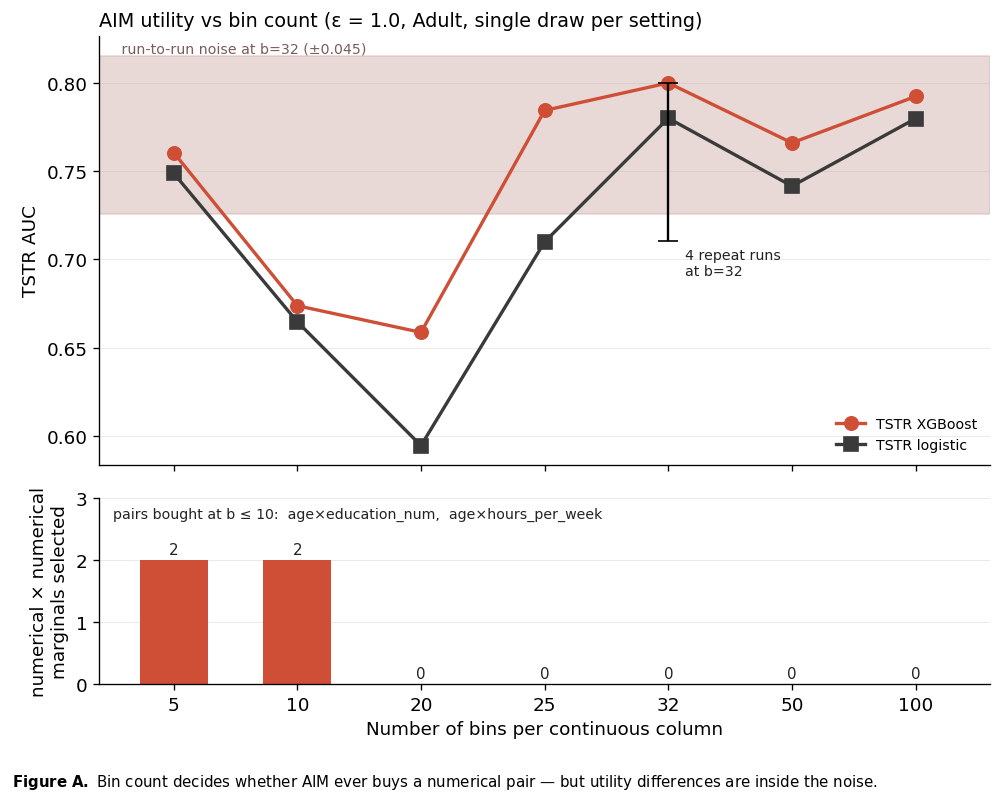

In [19]:
# Figure A — utility vs bin count, with the measured noise band, over the pair-count diagnostic.
# Two panels rather than a twin axis: AUC and a raw count are different scales.
x = np.arange(len(tune))
xi = int(tune.index[tune['bins'] == peak_b][0])
peak_mean = draws.mean()

fig, axes = plt.subplots(2, 1, figsize=(8.4, 6.8), sharex=True,
                         gridspec_kw={'height_ratios': [2.3, 1]})

ax = axes[0]
ax.axhspan(peak_mean - WOBBLE / 2, peak_mean + WOBBLE / 2, color=PINK, alpha=0.5, zorder=0)
ax.text(0.02, peak_mean + WOBBLE / 2, f' run-to-run noise at b={peak_b} (±{WOBBLE/2:.3f})',
        transform=ax.get_yaxis_transform(), ha='left', va='bottom', fontsize=8.5, color='#7a5c5a')
ax.plot(x, tune['xgb_syn_id'], '-o', color=ORANGE, lw=2, ms=8, zorder=3, label='TSTR XGBoost')
ax.plot(x, tune['linear_syn_id'], '-s', color=GREY, lw=2, ms=8, zorder=3, label='TSTR logistic')
ax.errorbar(xi, peak_mean, yerr=[[peak_mean - draws.min()], [draws.max() - peak_mean]],
            fmt='none', ecolor='black', capsize=6, elinewidth=1.4, zorder=4)
ax.annotate(f'{len(draws)} repeat runs\nat b={peak_b}', (xi, draws.min()),
            textcoords='offset points', xytext=(10, -4), fontsize=8.5, va='top', color='#222222')
ax.set_ylabel('TSTR AUC')
ax.set_title('AIM utility vs bin count (ε = 1.0, Adult, single draw per setting)',
             fontsize=11.5, loc='left')
ax.legend(fontsize=8.5, frameon=False, loc='lower right')

ax = axes[1]
ax.bar(x, tune['n_numeric_pairs'], color=ORANGE, width=0.55)
for xj, v in zip(x, tune['n_numeric_pairs']):
    ax.text(xj, v + 0.05, str(int(v)), ha='center', va='bottom', fontsize=9, color='#222222')
ax.set_ylim(0, max(2.6, tune['n_numeric_pairs'].max() * 1.5))
ax.set_ylabel('numerical × numerical\nmarginals selected')
ax.set_xlabel('Number of bins per continuous column')
ax.set_xticks(x)
ax.set_xticklabels(tune['bins'].astype(int))
ax.text(0.015, 0.95, 'pairs bought at b ≤ 10:  age×education_num,  age×hours_per_week',
        transform=ax.transAxes, va='top', ha='left', fontsize=8.5, color='#222222')

for a in axes:
    a.grid(axis='y', lw=0.5, alpha=0.3)
    a.set_axisbelow(True)
    for s in ('top', 'right'):
        a.spines[s].set_visible(False)

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.01, 0.02,
         r"$\bf{Figure\ A.}$ Bin count decides whether AIM ever buys a numerical pair — "
         "but utility differences are inside the noise.",
         ha='left', va='bottom', fontsize=9)
plt.savefig(TUNING / 'aim_tuning_utility.png', bbox_inches='tight')
plt.show()

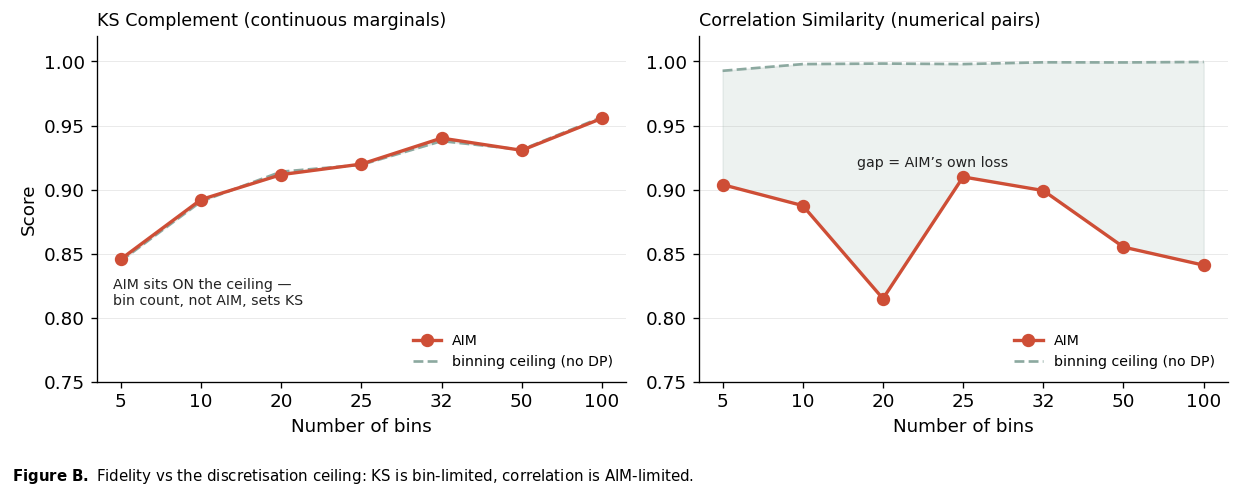

In [20]:
# Figure B — fidelity against the discretisation ceiling.
# Ceiling = real data pushed through encode->decode with AIM removed, i.e. the best
# score achievable at that bin count. The shaded gap is AIM's own loss.
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.2), sharex=True)

for ax, metric, title in [
    (axes[0], 'KSComplement', 'KS Complement (continuous marginals)'),
    (axes[1], 'CorrelationSimilarity', 'Correlation Similarity (numerical pairs)'),
]:
    ax.plot(x, tune[metric], '-o', color=ORANGE, lw=2, ms=7, label='AIM', zorder=3)
    ax.plot(x, tune[f'ceiling_{metric}'], '--', color=TEAL, lw=1.6,
            label='binning ceiling (no DP)', zorder=2)
    ax.fill_between(x, tune[metric], tune[f'ceiling_{metric}'], color=TEAL, alpha=0.15, zorder=1)
    ax.set_title(title, fontsize=10.5, loc='left')
    ax.set_xticks(x)
    ax.set_xticklabels(tune['bins'].astype(int))
    ax.set_xlabel('Number of bins')
    ax.set_ylim(0.75, 1.02)
    ax.grid(axis='y', lw=0.5, alpha=0.3)
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    ax.legend(fontsize=8.5, frameon=False, loc='lower right')

axes[0].set_ylabel('Score')
axes[0].text(0.03, 0.30, 'AIM sits ON the ceiling —\nbin count, not AIM, sets KS',
             transform=axes[0].transAxes, fontsize=8.5, color='#222222', va='top')
axes[1].text(0.30, 0.62, 'gap = AIM’s own loss', transform=axes[1].transAxes,
             fontsize=8.5, color='#222222')

plt.tight_layout(rect=[0, 0.08, 1, 1])
fig.text(0.01, 0.02,
         r"$\bf{Figure\ B.}$ Fidelity vs the discretisation ceiling: KS is bin-limited, "
         "correlation is AIM-limited.",
         ha='left', va='bottom', fontsize=9)
plt.savefig(TUNING / 'aim_tuning_fidelity.png', bbox_inches='tight')
plt.show()

## AIM at the chosen bin count (b = 32)

The AIM row in `results/*.csv` is still the **b = 20** run (SmartNoise's default), which is what
motivated the sweep. The chosen setting is **b = 32** — the AIM paper's own preprocessing
(McKenna et al. 2022, Appendix A: *"We discretize each numerical attribute into 32 equal-width
bins, using the min/max values from the domain file"*), and the top of our sweep.

Its metrics come from the tuning harness, which calls the same SDMetrics and Synthcity functions:
`aim_tuning_results.csv` (the sweep run) plus `aim_tuning_repeats.csv` (3 repeats) — 4 draws in
total, so AIM is plotted as the **mean with min–max whiskers** while the other four remain single
runs. Nothing below is hardcoded.

Once `sdg/aim.py` is regenerated at b = 32 and both eval scripts rerun, `results/*.csv` becomes
authoritative and this section can just read from there.

In [21]:
# Assemble AIM's chosen-bin row from the tuning CSVs.
# FIDELITY ONLY. The tuning CSVs' utility columns (xgb_syn_id, linear_syn_id) come
# from synthcity's leaky Metrics.evaluate and are NOT comparable to the leak-free
# TSTR in results/utility_summary.csv, so they are deliberately not merged here.
# See the KNOWN ISSUE header in sdg/aim_tuning/aim_tuning.py.
CHOSEN_BINS = 32
TUNING = Path('../sdg/aim_tuning')

tune = pd.read_csv(TUNING / 'aim_tuning_results.csv')
reps = pd.read_csv(TUNING / 'aim_tuning_repeats.csv')
aim_draws = pd.concat([tune[tune['bins'] == CHOSEN_BINS], reps[reps['bins'] == CHOSEN_BINS]],
                      ignore_index=True)

FID_COLS = ['KSComplement', 'TVComplement', 'CorrelationSimilarity', 'ContingencySimilarity']
aim32_mean = aim_draws[FID_COLS].mean()
aim32_min  = aim_draws[FID_COLS].min()
aim32_max  = aim_draws[FID_COLS].max()

# copy with AIM's b=20 row swapped for the b=32 mean; the original is left untouched
sdm32 = sdm.copy()
for m in FID_COLS:
    sdm32.loc['AIM', m] = aim32_mean[m]

print(f'AIM b={CHOSEN_BINS}: {len(aim_draws)} draws (fidelity only)')
delta = pd.DataFrame({
    'b=20 (multi-run mean)': [sdm.loc['AIM', c] for c in FID_COLS],
    f'b={CHOSEN_BINS} (mean of {len(aim_draws)})': [aim32_mean[c] for c in FID_COLS],
}, index=FID_COLS)
delta['delta'] = delta.iloc[:, 1] - delta.iloc[:, 0]
delta.round(4)


AIM b=32: 4 draws


,b=20 (results CSV),b=32 (mean of 4),delta
KSComplement,0.9095,0.9380,0.0285
TVComplement,0.9827,0.9923,0.0096
CorrelationSimilarity,0.7963,0.8909,0.0946
ContingencySimilarity,0.9116,0.9531,0.0415
performance.xgb.syn_id,0.7239,0.7706,0.0467
performance.linear_model.syn_id,0.6585,0.7531,0.0946


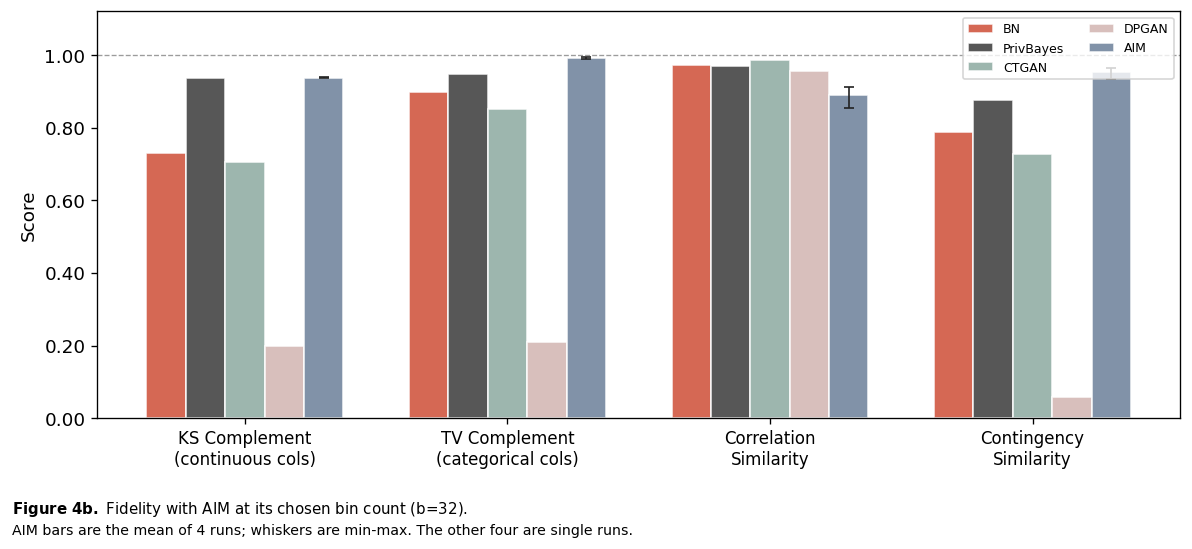

In [22]:
# Fidelity with AIM at its chosen bin count. AIM carries min-max whiskers over its 4 draws;
# the other four generators are single runs and have none.
fid = ['KSComplement', 'TVComplement', 'CorrelationSimilarity', 'ContingencySimilarity']
fid_labels = ['KS Complement\n(continuous cols)', 'TV Complement\n(categorical cols)',
              'Correlation\nSimilarity', 'Contingency\nSimilarity']

x = np.arange(len(fid)); width = 0.15
fig, ax = plt.subplots(figsize=(10, 4.6))
for i, m in enumerate(METHOD_ORDER):
    lab = METHOD_LABELS[m]
    off = x + (i - (len(METHOD_ORDER) - 1) / 2) * width
    vals = [sdm32.loc[lab, c] for c in fid]
    yerr = None
    if m == 'aim':
        yerr = np.array([[vals[j] - aim32_min[c] for j, c in enumerate(fid)],
                         [aim32_max[c] - vals[j] for j, c in enumerate(fid)]])
    ax.bar(off, vals, width, label=lab, color=COLORS[m], alpha=0.85, edgecolor='white',
           yerr=yerr, capsize=3, error_kw={'elinewidth': 1, 'ecolor': '#222222'})

ax.set_xticks(x); ax.set_xticklabels(fid_labels, fontsize=10)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.12)
ax.axhline(1.0, color=GREY, ls='--', lw=0.8, alpha=0.5)
ax.legend(loc='upper right', fontsize=7.5, ncol=2)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.tight_layout(rect=[0, 0.1, 1, 1])
fig.text(0.01, 0.045, r"$\bf{Figure\ 4b.}$ Fidelity with AIM at its chosen bin count "
                      f"(b={CHOSEN_BINS}).", ha='left', va='bottom', fontsize=9)
fig.text(0.01, 0.012, f"AIM bars are the mean of {len(aim_draws)} runs; whiskers are min-max. "
                      "The other four are single runs.", ha='left', va='bottom', fontsize=8.5)
plt.savefig(RESULTS / 'fidelity_comparison_b32.png', bbox_inches='tight')
plt.show()

### AIM b=32 utility comparison: SUPERSEDED pending the aim_tuning fix

This cell produced `results/utility_comparison_b32.png`, which has been deleted.

`sdg/aim_tuning/aim_tuning.py` still scores utility with synthcity's leaky
`Metrics.evaluate`, so its `xgb_syn_id` / `linear_syn_id` columns are not comparable
to the leak-free TSTR in `results/utility_summary.csv` — plotting them on one axis
would be misleading. See the KNOWN ISSUE header in that script; the fix is to swap in
`compute_tstr` from `evaluation/eval_utility.py` and re-run the sweep.

AIM's **fidelity** at b=32 is unaffected and is still plotted in the cell above.
